# Model Comparison V2 (Baseline vs Word2Vec vs DistilBERT)
Independent module to extract metrics and charts without retraining.

In [4]:
# 1. Environment Setup and Library Imports
import os
import sys
if 'google.colab' in sys.modules:
    !pip install -q transformers[torch] datasets evaluate accelerate umap-learn
    from google.colab import drive
    # Ensure a clean mount point by unmounting and removing its content if necessary
    try:
        drive.flush_and_unmount()
    except ValueError:
        pass # Already unmounted or never mounted
    !rm -rf /content/drive/*
    drive.mount('/content/drive', force_remount=True)
    BASE_PATH = '/content/drive/MyDrive/Project 2/project-nlp-challenge'
else:
    BASE_PATH = '.'

import pandas as pd
import numpy as np
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
import evaluate

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [5]:
# ==========================================
# Celda 2: Carga de Datos y Modelos Base
# ==========================================
import os
from datasets import Dataset

# 1. Carga del CSV con todas las columnas críticas
df = pd.read_csv(os.path.join(BASE_PATH, 'dataset/cleaned_data.csv'))
df['full_text'] = df['full_text'].fillna('')
df['cleaned_text'] = df['cleaned_text'].fillna('')

# Asegurar que el directorio de modelos está listo
os.makedirs(os.path.join(BASE_PATH, 'models'), exist_ok=True)

# 2. Creación del Dataset incluyendo 'cleaned_text' para Word2Vec
# Mantenemos el seed=42 para que el split sea idéntico a tus entrenamientos previos
dataset_full = Dataset.from_pandas(df[['full_text', 'cleaned_text', 'label']])
dataset_split = dataset_full.train_test_split(test_size=0.2, seed=42)

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["full_text"], padding="max_length", truncation=True)

print("Re-tokenizando test dataset con soporte completo...")
tokenized_datasets = dataset_split.map(tokenize_function, batched=True)

# 3. Carga del Modelo Transformer desde Drive
final_model_path = os.path.join(BASE_PATH, 'models/bert_results/checkpoint-1500')
print(f"Buscando modelo en: {final_model_path}")

if os.path.exists(final_model_path):
    model = AutoModelForSequenceClassification.from_pretrained(final_model_path)
    trainer = Trainer(model=model)
    print("✅ Transformer DistilBERT Cargado y Listo.")
else:
    print(f"❌ ERROR: No se encontró el checkpoint 1500 en {final_model_path}")
    print("Por favor, verifica la carpeta 'models/bert_results' en tu Drive.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/31908 [00:00<?, ? examples/s]

Map:   0%|          | 0/7978 [00:00<?, ? examples/s]

Buscando modelo en: /content/drive/MyDrive/Project 2/project-nlp-challenge/models/bert_results/checkpoint-1500


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Transformer DistilBERT Cargado y Listo.


## 6. Model Evaluation & Scientific Comparison
We evaluate the Transformer performance and compare it against the Phase 2 Semantic baseline using different visualization techniques.

### 6.1 Standard Metrics & Confusion Matrix
Baseline evaluation of the fine-tuned DistilBERT model.

Evaluating BERT on test data...



Classification Report:
              precision    recall  f1-score   support

   FAKE NEWS       1.00      1.00      1.00      3949
   REAL NEWS       1.00      1.00      1.00      4029

    accuracy                           1.00      7978
   macro avg       1.00      1.00      1.00      7978
weighted avg       1.00      1.00      1.00      7978



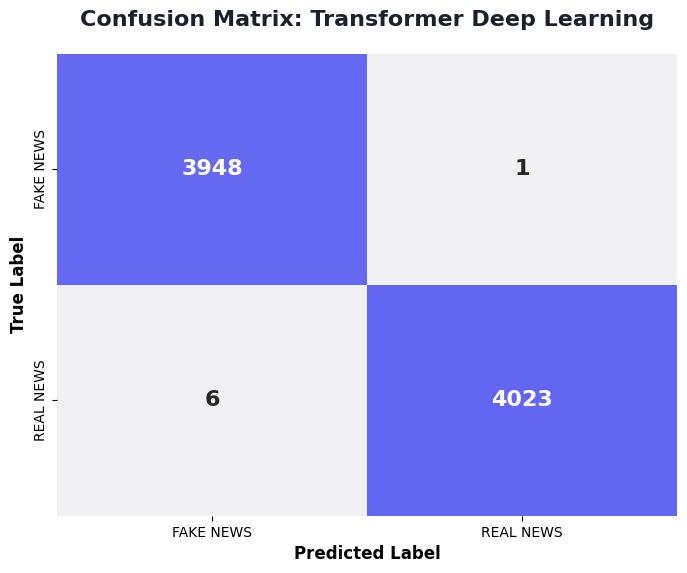

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Predictions on test set
print("Evaluating BERT on test data...")
predictions_output = trainer.predict(tokenized_datasets['test'])
predicted_labels = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

# 2. Classification Report
report = classification_report(true_labels, predicted_labels, target_names=['FAKE NEWS', 'REAL NEWS'])
print("\nClassification Report:")
print(report)

# 3. Confusion Matrix with Indigo Transformer Color
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette("#6366F1", as_cmap=True),
            xticklabels=['FAKE NEWS', 'REAL NEWS'],
            yticklabels=['FAKE NEWS', 'REAL NEWS'],
            cbar=False, annot_kws={"size": 16, "weight": "bold"})

plt.title('Confusion Matrix: Transformer Deep Learning', fontsize=16, fontweight='bold', pad=20, color='#1A202C')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.show()

### 6.2 ROC Curve Tournament (BERT vs Word2Vec)
Comparison of prediction confidence and separability between models.

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer guardado en: /content/drive/MyDrive/Project 2/project-nlp-challenge/models/distilbert_classifier
Cargando modelos base...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ Modelos cargados con éxito.
Calculando probabilidades...


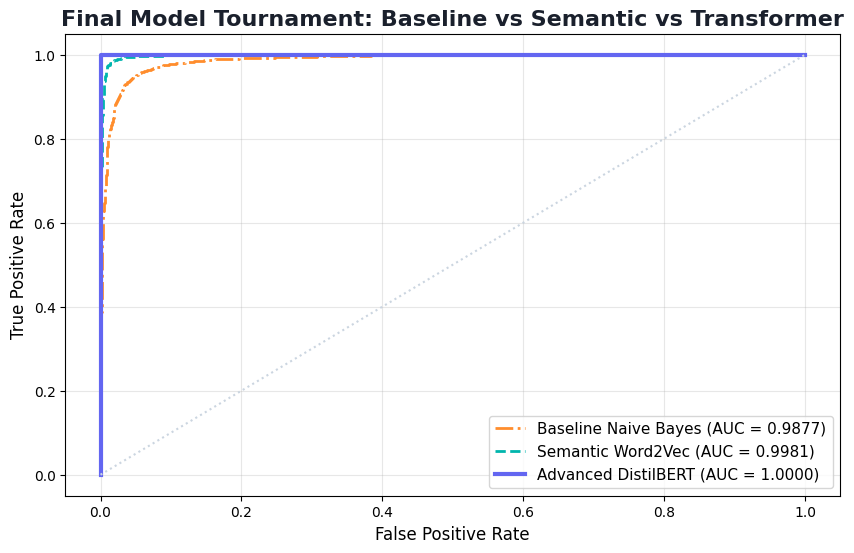

In [17]:
# ==========================================
# Celda 6.2: ROC Curve Tournament (FIXED)
# ==========================================
import joblib
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Install gensim if not already installed
try:
    from gensim.models import Word2Vec
except ImportError:
    !pip install -q gensim
    from gensim.models import Word2Vec

# 1. Guardar copia del Transformer
distilbert_path = os.path.join(BASE_PATH, 'models/distilbert_classifier')
trainer.save_model(distilbert_path)
print(f"Transformer guardado en: {distilbert_path}")

# 2. Carga de Modelos
print("Cargando modelos base...")
try:
    nb_tfidf = joblib.load(os.path.join(BASE_PATH, 'models/nb_tfidf_classifier.joblib'))
    tfidf_vec = joblib.load(os.path.join(BASE_PATH, 'models/vectorizer.joblib'))
    lr_w2v = joblib.load(os.path.join(BASE_PATH, 'models/lr_word2vec_classifier.joblib'))
    w2v_model = joblib.load(os.path.join(BASE_PATH, 'models/word2vec_model.joblib'))
    print("✅ Modelos cargados con éxito.")
except Exception as e:
    print(f"❌ ERROR CRÍTICO AL CARGAR MODELOS: {e}")
    # Detenemos la ejecución si no hay modelos, para no tener el NameError después
    raise e

# 3. Función Vectorizadora Fast
def document_vector(doc, model):
    words = [w for w in str(doc).split() if w in model.wv]
    if not words: return np.zeros(model.vector_size)
    return np.mean(model.wv[words], axis=0)

# 4. Cálculo de Probabilidades
print("Calculando probabilidades...")
test_texts = dataset_split['test']['cleaned_text']
y_true = predictions_output.label_ids

# Baseline
X_tfidf = tfidf_vec.transform(test_texts)
probs_nb = nb_tfidf.predict_proba(X_tfidf)[:, 1]

# Semantic (Word2Vec)
X_w2v = np.vstack([document_vector(t, w2v_model) for t in test_texts])
probs_w2v = lr_w2v.predict_proba(X_w2v)[:, 1]

# Transformer
probs_bert = torch.nn.functional.softmax(torch.tensor(predictions_output.predictions), dim=-1).numpy()[:, 1]

# Calculate ROC curves for each model
fpr_nb, tpr_nb, _ = roc_curve(y_true, probs_nb)
fpr_w, tpr_w, _ = roc_curve(y_true, probs_w2v)
fpr_b, tpr_b, _ = roc_curve(y_true, probs_bert)

# 5. Plot
plt.figure(figsize=(10, 6))

plt.plot(fpr_nb, tpr_nb, color='#FF8D2D', lw=2, linestyle='-.', label=f'Baseline Naive Bayes (AUC = {auc(fpr_nb, tpr_nb):.4f})')
plt.plot(fpr_w, tpr_w, color='#00B5AD', lw=2, linestyle='--', label=f'Semantic Word2Vec (AUC = {auc(fpr_w, tpr_w):.4f})')
plt.plot(fpr_b, tpr_b, color='#6366F1', lw=3, label=f'Advanced DistilBERT (AUC = {auc(fpr_b, tpr_b):.4f})')
plt.plot([0, 1], [0, 1], color='#CBD5E0', linestyle=':')

plt.title('Final Model Tournament: Baseline vs Semantic vs Transformer', fontsize=16, fontweight='bold', color='#1A202C')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.show()

### High-Dimensional Feature Extraction
We extract embeddings from both models for dimensionality reduction analysis.

In [13]:
# Sampling and extraction shared by PCA, t-SNE, and UMAP
sample_size = 1000
sample_indices = range(min(sample_size, len(tokenized_datasets['test'])))
bert_sample = tokenized_datasets['test'].select(sample_indices)

def get_cls_embeddings(batch):
    inputs = {k: torch.tensor(v).to(model.device) for k, v in batch.items() if k in ['input_ids', 'attention_mask']}
    with torch.no_grad():
        outputs = model.distilbert(**inputs)
        cls_state = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    return {'bert_embeddings': cls_state}

print("Extracting BERT CLS Embeddings...")
bert_sample = bert_sample.map(get_cls_embeddings, batched=True, batch_size=32)
emb_bert = np.array(bert_sample['bert_embeddings'])
labels_s = np.array(bert_sample['label'])

print("Extracting Word2Vec Avg Vectors...")
emb_w2v = np.vstack([document_vector(t, w2v_model) for t in dataset_split['test'].select(sample_indices)['full_text']])

def plot_comparison_modular(name, method_obj):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    colors = ['#FF8D2D', '#00B5AD']

    red_w2v = method_obj.fit_transform(emb_w2v)
    for label in [0, 1]:
        mask = labels_s == label
        axes[0].scatter(red_w2v[mask, 0], red_w2v[mask, 1], c=colors[label], label='Fake' if label==0 else 'Real', alpha=0.5)
    axes[0].set_title(f'Word2Vec Space ({name})', fontsize=14, fontweight='bold')

    red_bert = method_obj.fit_transform(emb_bert)
    for label in [0, 1]:
        mask = labels_s == label
        axes[1].scatter(red_bert[mask, 0], red_bert[mask, 1], c=colors[label], label='Fake' if label==0 else 'Real', alpha=0.5)
    axes[1].set_title(f'DistilBERT space ({name})', fontsize=14, fontweight='bold', color='#6366F1')

    plt.suptitle(f'Latent Space Comparison: {name}', fontsize=18, fontweight='bold', y=1.02)
    plt.show()

Extracting BERT CLS Embeddings...


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Extracting Word2Vec Avg Vectors...


### 6.3 PCA Comparison
Projecting the most significant variance dimensions.

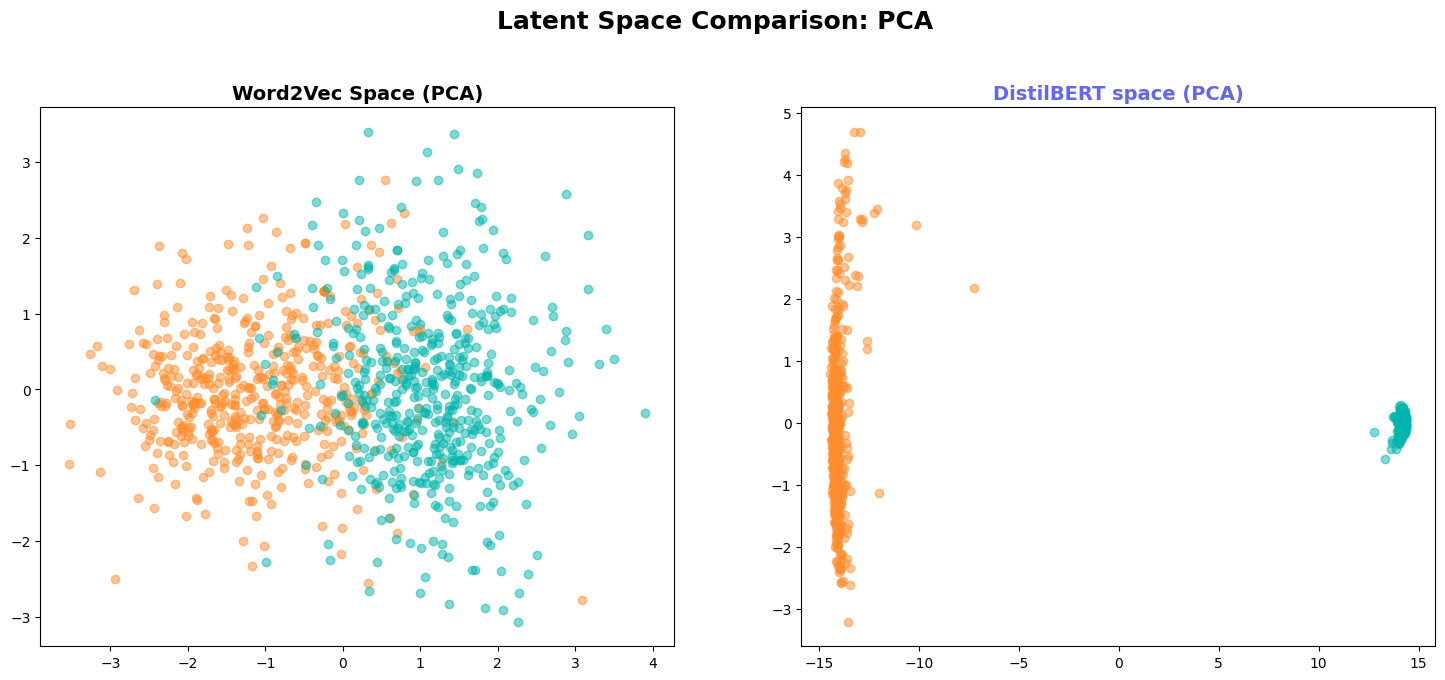

In [14]:
from sklearn.decomposition import PCA
plot_comparison_modular('PCA', PCA(n_components=2))

### 6.4 t-SNE Comparison
Visualizing local clusters and neighborhood structures.

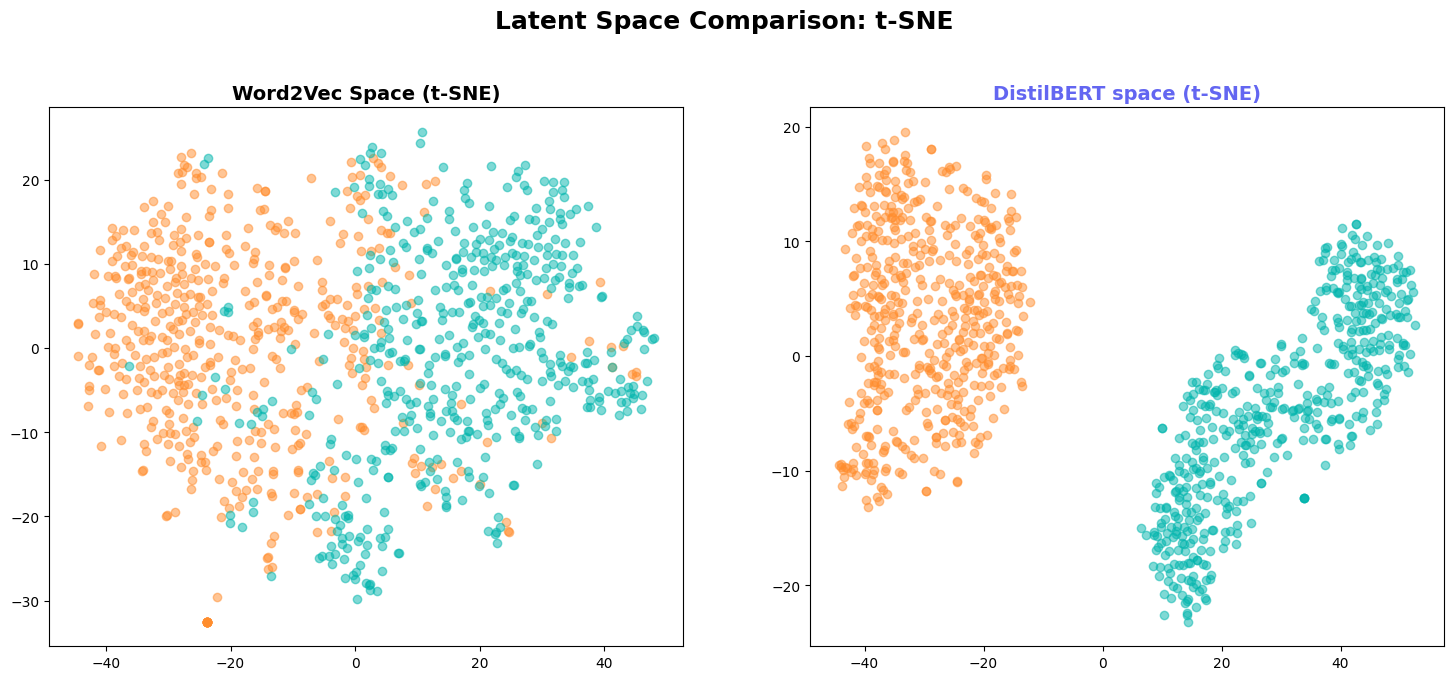

In [15]:
from sklearn.manifold import TSNE
plot_comparison_modular('t-SNE', TSNE(n_components=2, perplexity=30, random_state=42))

### 6.5 UMAP Comparison
Preserving global and local structure for better separability visualization.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


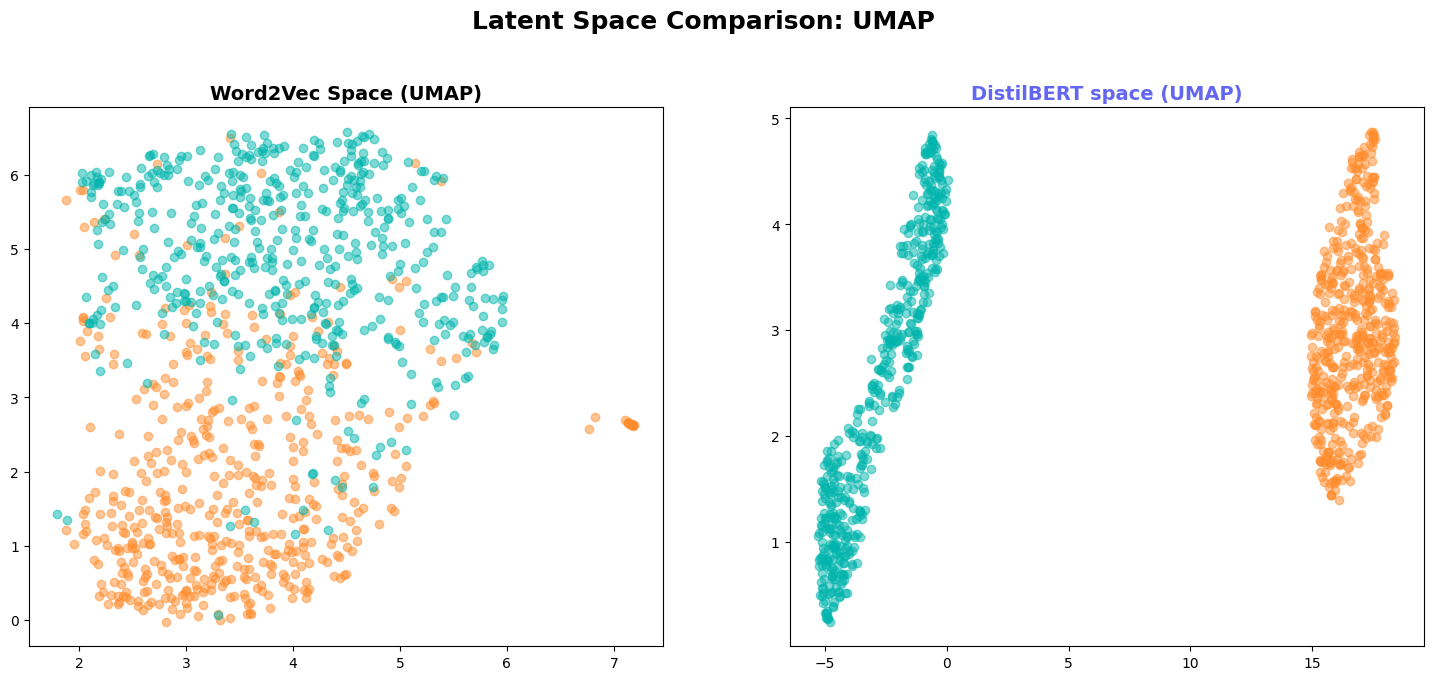

In [18]:
import umap.umap_ as umap
plot_comparison_modular('UMAP', umap.UMAP(n_neighbors=200, min_dist=0.1, random_state=42))